# Initialization & Data Cleaning

## Import libraries

In [44]:
import pandas as pd
import numpy as np
from pathlib import Path


## Load all monthly data

In [45]:

data_path = Path(".")
files = list(data_path.glob("*.csv"))

dfs = []
for file in files:
    df = pd.read_csv(file, sep="\t")
    df["source_file"] = file.name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Initial shape:", data.shape)
print("Columns:", data.columns)


Initial shape: (240447, 9)
Columns: Index(['sensor_id', 'sensor_type', 'location', 'lat', 'lon', 'timestamp',
       'value_type', 'value', 'source_file'],
      dtype='object')


##  Basic Cleaning

### Convert timestamp

In [46]:
data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")

### Drop critical missing values

In [47]:
data = data.dropna(subset=["timestamp", "lat", "lon", "value"])

### Remove Duplicates

In [48]:
data = data.drop_duplicates()

In [49]:
print("After basic cleaning:", data.shape)


After basic cleaning: (240447, 9)


### Convert to wide format

In [50]:
wide_df = (
    data
    .pivot_table(
        index=["sensor_id","location","lat","lon","timestamp"],
        columns="value_type",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)

print("After pivot:", wide_df.shape)
print(wide_df.columns)


After pivot: (94679, 10)
Index(['sensor_id', 'location', 'lat', 'lon', 'timestamp', 'P0', 'P1', 'P2',
       'humidity', 'temperature'],
      dtype='object', name='value_type')


### Rename columns

In [51]:
wide_df = wide_df.rename(columns={
    "P0": "PM1",
    "P1": "PM2_5",
    "P2": "PM10"
})

print(wide_df.columns)


Index(['sensor_id', 'location', 'lat', 'lon', 'timestamp', 'PM1', 'PM2_5',
       'PM10', 'humidity', 'temperature'],
      dtype='object', name='value_type')


### Handle missing values

In [52]:
wide_df = wide_df.sort_values(["sensor_id", "timestamp"])

feature_cols = ["PM1","PM2_5","PM10","humidity","temperature"]

# Forward fill per sensor
wide_df[feature_cols] = (
    wide_df
    .groupby("sensor_id")[feature_cols]
    .ffill()
)

# Sensor-wise median
for col in feature_cols:
    wide_df[col] = wide_df[col].fillna(
        wide_df.groupby("sensor_id")[col].transform("median")
    )

# Global fallback
wide_df[feature_cols] = wide_df[feature_cols].fillna(
    wide_df[feature_cols].median()
)

print("Remaining missing values:")
print(wide_df[feature_cols].isna().sum())


Remaining missing values:
value_type
PM1            0
PM2_5          0
PM10           0
humidity       0
temperature    0
dtype: int64


### Remove extreme outliers

In [53]:
# Remove physically impossible values
wide_df = wide_df[
    (wide_df["PM1"] >= 0) &
    (wide_df["PM2_5"] >= 0) &
    (wide_df["PM10"] >= 0)
]

# Clip extreme upper values ( in the 99th percentile )
for col in ["PM1","PM2_5","PM10"]:
    upper = wide_df[col].quantile(0.99)
    wide_df[col] = np.clip(wide_df[col], None, upper)



### Current dataset

In [54]:
print(wide_df.head(25))

value_type  sensor_id  location    lat  lon                        timestamp  \
0                4851      3627  6.515  3.4 2024-02-01 16:31:44.331333+00:00   
1                4851      3627  6.515  3.4 2024-02-01 16:38:14.403956+00:00   
2                4851      3627  6.515  3.4 2024-02-07 09:21:41.990049+00:00   
3                4851      3627  6.515  3.4 2024-02-07 09:22:47.488001+00:00   
4                4851      3627  6.515  3.4 2024-02-07 09:23:53.852311+00:00   
5                4851      3627  6.515  3.4 2024-02-07 09:24:58.682125+00:00   
6                4851      3627  6.515  3.4 2024-02-07 09:26:03.829223+00:00   
7                4851      3627  6.515  3.4 2024-02-07 09:27:15.204401+00:00   
8                4851      3627  6.515  3.4 2024-02-07 09:30:31.974137+00:00   
9                4851      3627  6.515  3.4 2024-02-07 09:31:36.540091+00:00   
10               4851      3627  6.515  3.4 2024-02-07 09:32:51.728187+00:00   
11               4851      3627  6.515  

# Feature Engineering

## Temporal Features

### Extract Hour

In [55]:
wide_df["hour"] = wide_df["timestamp"].dt.hour

### Extract Day of the week

In [56]:
wide_df["day_of_week"] = wide_df["timestamp"].dt.dayofweek

### Identify Weekend

In [57]:
wide_df["is_weekend"] = wide_df["day_of_week"].isin([5,6]).astype(int)

### Extract Month

In [58]:
wide_df["month"] = wide_df["timestamp"].dt.month

### Proper cyclical Encoding

In [59]:
wide_df["hour_sin"] = np.sin(2 * np.pi * wide_df["hour"] / 24)
wide_df["hour_cos"] = np.cos(2 * np.pi * wide_df["hour"] / 24)

## Pollutant Derived Features

### Total Particulate Load

In [60]:
wide_df["PM_total"] = wide_df["PM1"] + wide_df["PM2_5"] + wide_df["PM10"]


### Ratio of fine particles

In [61]:
wide_df["fine_ratio"] = wide_df["PM2_5"] / (wide_df["PM10"] + 1e-6)

### Ratio of coarse particles

In [62]:
wide_df["coarse_ratio"] = wide_df["PM10"] / (wide_df["PM2_5"] + 1e-6)

## Weather Interaction Features

### Pollution x Humidity Interaction

In [63]:
wide_df["PM_humidity_interaction"] = (
    wide_df["PM2_5"] * wide_df["humidity"]
)


### Pollution x temperature Interaction

In [64]:
wide_df["PM_temp_interaction"] = (
    wide_df["PM2_5"] * wide_df["temperature"]
)


## Daily Aggregation

In [65]:
wide_df["date"] = wide_df["timestamp"].dt.date

feature_cols = [
    "PM1","PM2_5","PM10",
    "PM_total",
    "fine_ratio","coarse_ratio",
    "humidity","temperature",
    "PM_humidity_interaction",
    "PM_temp_interaction"
]

daily_df = (
    wide_df
    .groupby(["sensor_id","location","lat","lon","date"])[feature_cols]
    .mean()
    .reset_index()
)

print(daily_df.shape)


(641, 15)


## Pollution Severity Index

In [66]:
from sklearn.preprocessing import StandardScaler

scaler_temp = StandardScaler()
pollution_scaled = scaler_temp.fit_transform(
    daily_df[["PM1","PM2_5","PM10"]]
)

daily_df["pollution_index"] = pollution_scaled.mean(axis=1)


In [67]:
print(wide_df[["PM1","PM2_5","PM10",
    "PM_total",
    "fine_ratio","coarse_ratio",
    "humidity","temperature",
    "PM_humidity_interaction",
    "PM_temp_interaction"]].head(30))

value_type    PM1   PM2_5    PM10  PM_total  fine_ratio  coarse_ratio  \
0           35.71   68.71   53.57    157.99    1.282621      0.779654   
1           39.78   72.00   56.89    168.67    1.265600      0.790139   
2           24.90   48.90   38.40    112.20    1.273437      0.785276   
3           27.00   52.33   39.33    118.66    1.330536      0.751577   
4           70.00  121.00  110.00    301.00    1.100000      0.909091   
5           70.00  121.00  110.00    301.00    1.100000      0.909091   
6           70.00  121.00  110.00    301.00    1.100000      0.909091   
7           70.00  121.00  110.00    301.00    1.100000      0.909091   
8           70.00  121.00  110.00    301.00    1.100000      0.909091   
9           70.00  121.00  110.00    301.00    1.100000      0.909091   
10          70.00  121.00  110.00    301.00    1.100000      0.909091   
11          70.00  121.00  110.00    301.00    1.100000      0.909091   
12          70.00  121.00  110.00    301.00    1.10

## Feature selection & scaling

### Select final features for clustering

In [68]:
cluster_features = [
    "PM1",
    "PM2_5",
    "PM10",
    "fine_ratio",
    "humidity",
    "temperature"
]
X = daily_df[cluster_features]



### Standard Scaling

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Dimensionality Reduction
- Reduce to 2D for visualization

In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.55349147 0.23931228]


### Find Optimal K(Elbow Method)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

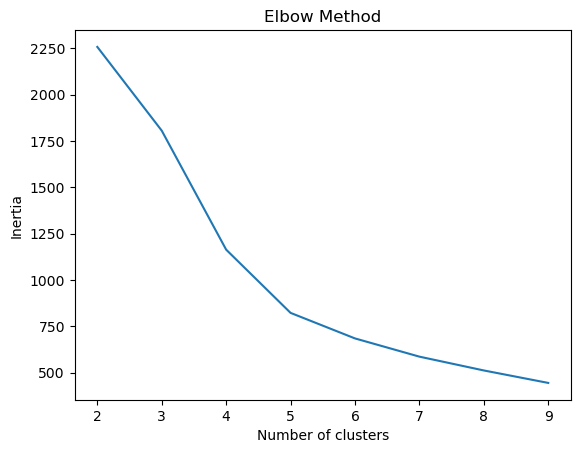

In [71]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(range(2,10), inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


### Find Optimal K(Sillhouette Score)

In [72]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette={score:.3f}")


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=2, Silhouette=0.526


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

K=3, Silhouette=0.338
K=4, Silhouette=0.478


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=5, Silhouette=0.419


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=6, Silhouette=0.420


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=7, Silhouette=0.422


In [73]:
kmeans = KMeans(n_clusters=7, random_state=42)
labels = kmeans.fit_predict(X_scaled)

daily_df["kmeans_cluster"] = labels


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


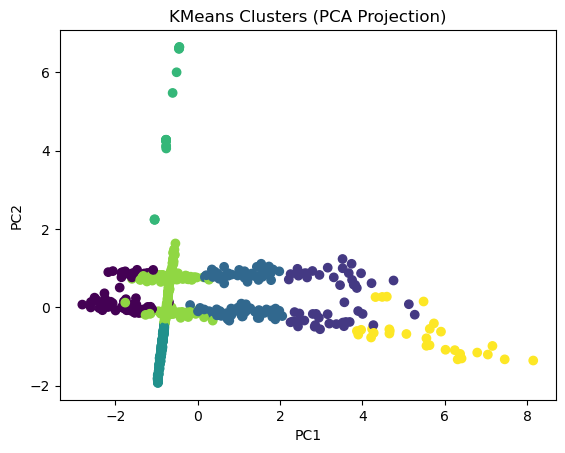

In [74]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


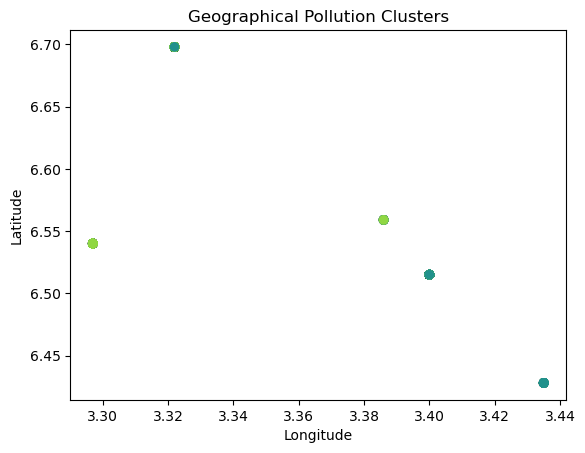

: 

In [ ]:
plt.figure()
plt.scatter(
    daily_df["lon"],
    daily_df["lat"],
    c=daily_df["kmeans_cluster"]
)
plt.title("Geographical Pollution Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
